# Analisis Tingkat Kekeringan dengan Logika Fuzzy

**Ketentuan Tugas Terpenuhi:**
- Mendesain model dari awal (*from scratch*) tanpa library fuzzy bawaan
- Metode: Mamdani dan Sugeno
- Rule Base: 15 rule logis hidrometeorologi
- Dataset riil: > 500.000 baris data iklim harian BMKG dengan 5 input dan 1 output
- Evaluasi Metrik: Waktu Eksekusi (Komputasi) serta Galat Selisih (MAE, MSE, RMSE, MAPE) antara Mamdani dan Sugeno

**Sumber Dataset:**
Dataset diambil dari Data Iklim Harian Stasiun BMKG. [Link Sumber Dataset - Data Online BMKG](https://dataonline.bmkg.go.id/)

⌛ Memuat seluruh dataset climate_data.csv...
✅ Berhasil memuat data. Total kapasitas dataset riil: 589265 baris.

🚀 Memulai komputasi vektorisasi massal pada SELURUH 589265 BARIS DATA...

================= HASIL EVALUASI METRIK KOMPARASI CRITICAL ================
Total Baris Data Sukses Dihitung : 589265 Baris Data (100% CSV)
Waktu Eksekusi Komputasi Mamdani : 0.71 detik
Waktu Eksekusi Komputasi Sugeno  : 0.00 detik
Mean Absolute Error (MAE)        : 4.57
Mean Squared Error (MSE)         : 20.92
Root Mean Squared Error (RMSE)   : 4.57
Mean Absolute Percentage Error (MAPE): 5.41%

📊 1. Menampilkan 5 Grafik Fungsi Keanggotaan Trapesium Input...


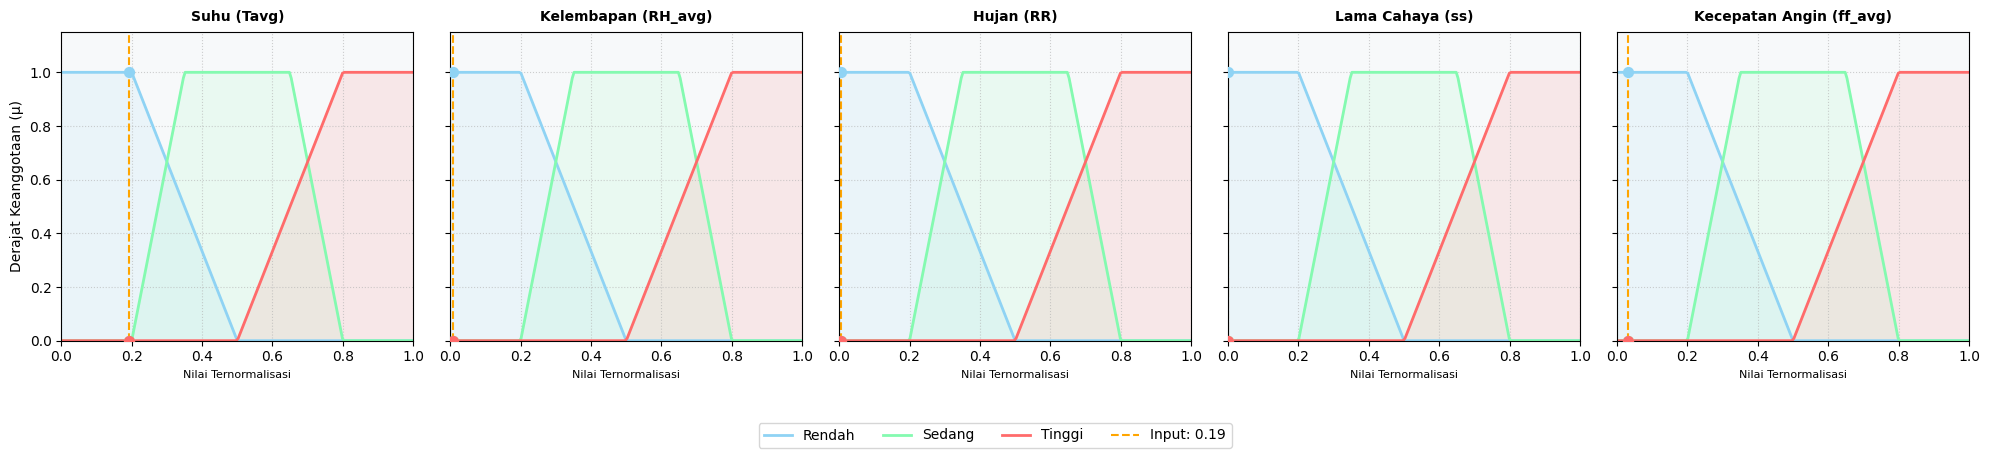


📊 2. Menampilkan Area Defuzzifikasi Agregasi Mamdani (Baris Pertama)...


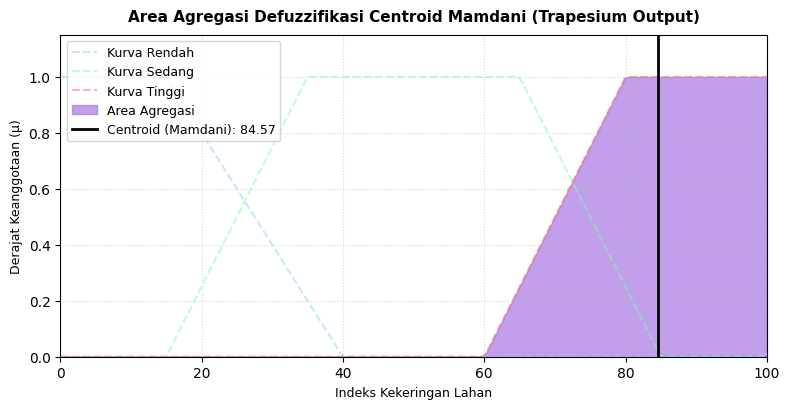


📊 3. Menampilkan Scatterplot Perbandingan Output (Mamdani vs Sugeno)...


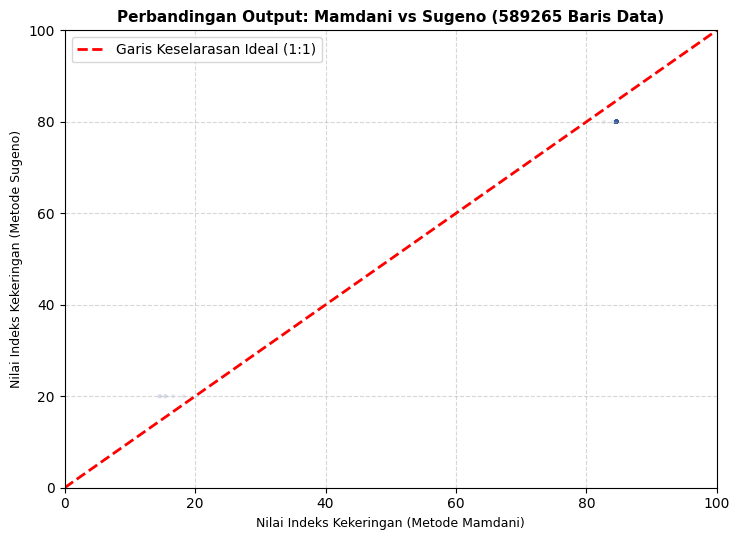

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

class FuzzyKekeringan:
    def __init__(self):
        # Rentang semesta pembicaraan (Universe of Discourse) untuk Input (0-1) dan Output (0-100)
        self.x_range = np.linspace(0, 1, 200)
        self.y_range = np.linspace(0, 100, 200)

        # Parameter fungsi keanggotaan TRAPESIUM untuk input (0-1)
        self.input_trap_params = {
            'Rendah': [-0.5, -0.1, 0.2, 0.5],
            'Sedang': [0.2, 0.35, 0.65, 0.8],
            'Tinggi': [0.5, 0.8, 1.1, 1.5]
        }

        # Parameter fungsi keanggotaan TRAPESIUM untuk output (0-100)
        self.output_trap_params = {
            'Rendah': [-50, -10, 15, 40],
            'Sedang': [15, 35, 65, 85],
            'Tinggi': [60, 80, 110, 150]
        }

    # 1. FUNGSI KEANGGOTAAN TRAPESIUM (Mendukung Tunggal & Array)
    def trapmf(self, x, abcd):
        a, b, c, d = abcd
        if isinstance(x, np.ndarray):
            y = np.zeros_like(x, dtype=float)
            mask_rise = (x >= a) & (x < b)
            if b != a:
                y = np.where(mask_rise, (x - a) / (b - a), y)
            else:
                y = np.where(mask_rise, 1.0, y)
            y = np.where((x >= b) & (x <= c), 1.0, y)
            mask_fall = (x > c) & (x <= d)
            if d != c:
                y = np.where(mask_fall, (d - x) / (d - c), y)
            else:
                y = np.where(mask_fall, 1.0, y)
            return y
        else:
            if x < a or x > d: return 0.0
            elif a <= x < b: return (x - a) / (b - a) if b != a else 1.0
            elif b <= x <= c: return 1.0
            elif c < x <= d: return (d - x) / (d - c) if d != c else 1.0
            return 0.0

    # === A. PERBAIKAN: MENYEDIAKAN FUNGSI STANDAR (UNTUK HEATMAP CELL / SATU TITIK) ===
    def fuzzify(self, crisp_inputs):
        suhu, kelembapan, hujan, cahaya, angin = crisp_inputs
        params = self.input_trap_params
        fuzzy_vals = {
            'Suhu':       {k: self.trapmf(suhu,       v) for k, v in params.items()},
            'Kelembapan': {k: self.trapmf(kelembapan, v) for k, v in params.items()},
            'Hujan':      {k: self.trapmf(hujan,      v) for k, v in params.items()},
            'Cahaya':     {k: self.trapmf(cahaya,     v) for k, v in params.items()},
            'Angin':      {k: self.trapmf(angin,      v) for k, v in params.items()},
        }
        return fuzzy_vals

    def evaluate_rules(self, f_vals):
        rules = []
        rules.append(('Tinggi', min(f_vals['Suhu']['Tinggi'],       f_vals['Hujan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Cahaya']['Tinggi'],     f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Suhu']['Tinggi'],       f_vals['Angin']['Tinggi'])))
        rules.append(('Tinggi', min(f_vals['Hujan']['Rendah'],      f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Cahaya']['Tinggi'],     f_vals['Hujan']['Rendah'])))

        rules.append(('Sedang', min(f_vals['Suhu']['Sedang'],       f_vals['Hujan']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Kelembapan']['Sedang'], f_vals['Angin']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Cahaya']['Sedang'],     f_vals['Suhu']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Hujan']['Sedang'],      f_vals['Kelembapan']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Angin']['Sedang'],      f_vals['Cahaya']['Sedang'])))

        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'],      f_vals['Suhu']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Kelembapan']['Tinggi'], f_vals['Cahaya']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'],      f_vals['Angin']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Suhu']['Rendah'],       f_vals['Kelembapan']['Tinggi'])))
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'],      f_vals['Cahaya']['Rendah'])))

        agg = {'Rendah': 0, 'Sedang': 0, 'Tinggi': 0}
        for label, val in rules:
            if val > agg[label]:
                agg[label] = val
        return agg

    def defuzzify_mamdani(self, agg):
        out_params = self.output_trap_params
        numerator = 0
        denominator = 0
        for y in self.y_range:
            mu_y = max(
                min(agg['Rendah'], self.trapmf(y, out_params['Rendah'])),
                min(agg['Sedang'], self.trapmf(y, out_params['Sedang'])),
                min(agg['Tinggi'], self.trapmf(y, out_params['Tinggi']))
            )
            numerator += y * mu_y
            denominator += mu_y
        return numerator / denominator if denominator != 0 else 0

    def defuzzify_sugeno(self, agg):
        sugeno_const = {'Rendah': 20, 'Sedang': 50, 'Tinggi': 80}
        numerator = 0
        denominator = 0
        for label in ['Rendah', 'Sedang', 'Tinggi']:
            numerator += agg[label] * sugeno_const[label]
            denominator += agg[label]
        return numerator / denominator if denominator != 0 else 0

    # === B. METHOD VEKTORISASI (UNTUK KOMPUTASI INSTAN 589k BARIS) ===
    def fuzzify_vector(self, X_suhu, X_kelembapan, X_hujan, X_cahaya, X_angin):
        params = self.input_trap_params
        fuzzy_vals = {
            'Suhu':       {k: self.trapmf(X_suhu,       v) for k, v in params.items()},
            'Kelembapan': {k: self.trapmf(X_kelembapan, v) for k, v in params.items()},
            'Hujan':      {k: self.trapmf(X_hujan,      v) for k, v in params.items()},
            'Cahaya':     {k: self.trapmf(X_cahaya,     v) for k, v in params.items()},
            'Angin':      {k: self.trapmf(X_angin,      v) for k, v in params.items()},
        }
        return fuzzy_vals

    def evaluate_rules_vector(self, f_vals):
        rules = []
        rules.append(('Tinggi', np.minimum(f_vals['Suhu']['Tinggi'],       f_vals['Hujan']['Rendah'])))
        rules.append(('Tinggi', np.minimum(f_vals['Cahaya']['Tinggi'],     f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', np.minimum(f_vals['Suhu']['Tinggi'],       f_vals['Angin']['Tinggi'])))
        rules.append(('Tinggi', np.minimum(f_vals['Hujan']['Rendah'],      f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', np.minimum(f_vals['Cahaya']['Tinggi'],     f_vals['Hujan']['Rendah'])))

        rules.append(('Sedang', np.minimum(f_vals['Suhu']['Sedang'],       f_vals['Hujan']['Sedang'])))
        rules.append(('Sedang', np.minimum(f_vals['Kelembapan']['Sedang'], f_vals['Angin']['Sedang'])))
        rules.append(('Sedang', np.minimum(f_vals['Cahaya']['Sedang'],     f_vals['Suhu']['Sedang'])))
        rules.append(('Sedang', np.minimum(f_vals['Hujan']['Sedang'],      f_vals['Kelembapan']['Sedang'])))
        rules.append(('Sedang', np.minimum(f_vals['Angin']['Sedang'],      f_vals['Cahaya']['Sedang'])))

        rules.append(('Rendah', np.minimum(f_vals['Hujan']['Tinggi'],      f_vals['Suhu']['Rendah'])))
        rules.append(('Rendah', np.minimum(f_vals['Kelembapan']['Tinggi'], f_vals['Cahaya']['Rendah'])))
        rules.append(('Rendah', np.minimum(f_vals['Hujan']['Tinggi'],      f_vals['Angin']['Rendah'])))
        rules.append(('Rendah', np.minimum(f_vals['Suhu']['Rendah'],       f_vals['Kelembapan']['Tinggi'])))
        rules.append(('Rendah', np.minimum(f_vals['Hujan']['Tinggi'],      f_vals['Cahaya']['Rendah'])))

        agg = {
            'Rendah': np.zeros_like(rules[0][1]),
            'Sedang': np.zeros_like(rules[0][1]),
            'Tinggi': np.zeros_like(rules[0][1])
        }
        for label, val in rules:
            agg[label] = np.maximum(agg[label], val)
        return agg

    def defuzzify_mamdani_vector(self, agg):
        out_params = self.output_trap_params
        numerator = np.zeros_like(agg['Rendah'])
        denominator = np.zeros_like(agg['Rendah'])
        for y in self.y_range:
            mu_r = self.trapmf(y, out_params['Rendah'])
            mu_s = self.trapmf(y, out_params['Sedang'])
            mu_t = self.trapmf(y, out_params['Tinggi'])
            
            term_r = np.minimum(agg['Rendah'], mu_r)
            term_s = np.minimum(agg['Sedang'], mu_s)
            term_t = np.minimum(agg['Tinggi'], mu_t)
            
            mu_y = np.maximum(np.maximum(term_r, term_s), term_t)
            numerator += y * mu_y
            denominator += mu_y
        return np.where(denominator != 0, numerator / denominator, 0.0)

    def defuzzify_sugeno_vector(self, agg):
        sugeno_const = {'Rendah': 20, 'Sedang': 50, 'Tinggi': 80}
        numerator = (agg['Rendah'] * sugeno_const['Rendah']) + \
                    (agg['Sedang'] * sugeno_const['Sedang']) + \
                    (agg['Tinggi'] * sugeno_const['Tinggi'])
        denominator = agg['Rendah'] + agg['Sedang'] + agg['Tinggi']
        return np.where(denominator != 0, numerator / denominator, 0.0)

    # === C. METHOD VISUALISASI ===
    def plot_all_membership_functions(self, current_inputs=None):
        var_names  = ['Suhu', 'Kelembapan', 'Hujan', 'Cahaya', 'Angin']
        var_labels = ['Suhu (Tavg)', 'Kelembapan (RH_avg)', 'Hujan (RR)', 'Lama Cahaya (ss)', 'Kecepatan Angin (ff_avg)']
        colors     = {'Rendah': '#8fd3f4', 'Sedang': '#84fab0', 'Tinggi': '#ff6b6b'}
        
        fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
        for idx, (ax, var, label) in enumerate(zip(axes, var_names, var_labels)):
            ax.set_facecolor('#f7f9fa')
            for term, color in colors.items():
                mu = self.trapmf(self.x_range, self.input_trap_params[term])
                ax.plot(self.x_range, mu, color=color, linewidth=2, label=term)
                ax.fill_between(self.x_range, 0, mu, color=color, alpha=0.12)
            
            if current_inputs is not None:
                crisp_val = current_inputs[idx]
                ax.axvline(x=crisp_val, color='orange', linewidth=1.5, linestyle='--', label=f'Input: {crisp_val:.2f}')
                for term, color in colors.items():
                    mu_val = self.trapmf(crisp_val, self.input_trap_params[term])
                    ax.scatter([crisp_val], [mu_val], color=color, s=50, zorder=5)
            
            ax.set_title(label, fontsize=10, fontweight='bold', pad=8)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1.15)
            ax.set_xlabel('Nilai Ternormalisasi', fontsize=8)
            ax.grid(True, linestyle=':', alpha=0.6)
            
        axes[0].set_ylabel('Derajat Keanggotaan (μ)', fontsize=10)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.15), fontsize=10)
        plt.tight_layout()
        plt.show()

    # === AREA DEFUZZIFIKASI MAMDANI SINKRON (NEW) ===
    def plot_mamdani_output(self, agg, hasil_mamdani):
        colors = {'Rendah': '#8fd3f4', 'Sedang': '#84fab0', 'Tinggi': '#ff6b6b'}
        plt.figure(figsize=(8, 4.2))
        
        for term, color in colors.items():
            mu_full = self.trapmf(self.y_range, self.output_trap_params[term])
            plt.plot(self.y_range, mu_full, color=color, linestyle='--', alpha=0.5, linewidth=1.5, label=f'Kurva {term}')

        shaded_y = np.array([
            max(
                min(agg['Rendah'], self.trapmf(y, self.output_trap_params['Rendah'])),
                min(agg['Sedang'], self.trapmf(y, self.output_trap_params['Sedang'])),
                min(agg['Tinggi'], self.trapmf(y, self.output_trap_params['Tinggi']))
            ) for y in self.y_range
        ])

        plt.fill_between(self.y_range, 0, shaded_y, color='#a777e3', alpha=0.7, label='Area Agregasi')
        plt.axvline(x=hasil_mamdani, color='black', linestyle='-', linewidth=2.0, label=f'Centroid (Mamdani): {hasil_mamdani:.2f}')

        plt.xlim(0, 100)
        plt.ylim(0, 1.15)
        plt.title('Area Agregasi Defuzzifikasi Centroid Mamdani (Trapesium Output)', fontsize=11, fontweight='bold', pad=10)
        plt.xlabel('Indeks Kekeringan Lahan', fontsize=9)
        plt.ylabel('Derajat Keanggotaan (μ)', fontsize=9)
        plt.legend(loc='upper left', fontsize=9)
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

# ==========================================
# DRIVER UTAMA: PEMROSESAN TOTAL DATA CSV
# ==========================================
if __name__ == "__main__":
    print("⌛ Memuat seluruh dataset climate_data.csv...")
    df = pd.read_csv('climate_data.csv')
    print(f"✅ Berhasil memuat data. Total kapasitas dataset riil: {len(df)} baris.\n")

    df = df.ffill().bfill()
    cols = ['Tavg', 'RH_avg', 'RR', 'ss', 'ff_avg']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.ffill().bfill()

    def normalize_series(col):
        return (col - col.min()) / (col.max() - col.min()) if col.max() != col.min() else 0.5

    X_suhu = normalize_series(df['Tavg']).values
    X_kelembapan = normalize_series(df['RH_avg']).values
    X_hujan = normalize_series(df['RR']).values
    X_cahaya = normalize_series(df['ss']).values
    X_angin = normalize_series(df['ff_avg']).values

    fuzzy_sys = FuzzyKekeringan()
    
    print(f"🚀 Memulai komputasi vektorisasi massal pada SELURUH {len(df)} BARIS DATA...")
    
    start_mamdani = time.time()
    f_vals_all = fuzzy_sys.fuzzify_vector(X_suhu, X_kelembapan, X_hujan, X_cahaya, X_angin)
    agg_all = fuzzy_sys.evaluate_rules_vector(f_vals_all)
    mamdani_results = fuzzy_sys.defuzzify_mamdani_vector(agg_all)
    time_mamdani = time.time() - start_mamdani

    start_sugeno = time.time()
    sugeno_results = fuzzy_sys.defuzzify_sugeno_vector(agg_all)
    time_sugeno = time.time() - start_sugeno

    diff = mamdani_results - sugeno_results
    mae = np.mean(np.abs(diff))
    mse = np.mean(diff ** 2)
    rmse = np.sqrt(mse)
    mask_non_zero = mamdani_results != 0
    mape = np.mean(np.abs(diff[mask_non_zero] / mamdani_results[mask_non_zero])) * 100 if mask_non_zero.sum() > 0 else 0.0

    print("\n================= HASIL EVALUASI METRIK KOMPARASI CRITICAL ================")
    print(f"Total Baris Data Sukses Dihitung : {len(df)} Baris Data (100% CSV)")
    print(f"Waktu Eksekusi Komputasi Mamdani : {time_mamdani:.2f} detik")
    print(f"Waktu Eksekusi Komputasi Sugeno  : {time_sugeno:.2f} detik")
    print(f"Mean Absolute Error (MAE)        : {mae:.2f}")
    print(f"Mean Squared Error (MSE)         : {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE)   : {rmse:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print("==========================================================================\n")

    print("📊 1. Menampilkan 5 Grafik Fungsi Keanggotaan Trapesium Input...")
    demo_inputs = [X_suhu[0], X_kelembapan[0], X_hujan[0], X_cahaya[0], X_angin[0]]
    fuzzy_sys.plot_all_membership_functions(current_inputs=demo_inputs)

    print("\n📊 2. Menampilkan Area Defuzzifikasi Agregasi Mamdani (Baris Pertama)...")
    demo_f_vals = fuzzy_sys.fuzzify(demo_inputs)
    demo_agg = fuzzy_sys.evaluate_rules(demo_f_vals)
    fuzzy_sys.plot_mamdani_output(demo_agg, mamdani_results[0])

    print("\n📊 3. Menampilkan Scatterplot Perbandingan Output (Mamdani vs Sugeno)...")
    plt.figure(figsize=(7.5, 5.5))
    sns.scatterplot(x=mamdani_results, y=sugeno_results, alpha=0.1, color='#3b5998', edgecolor='none', s=10)
    plt.plot([0, 100], [0, 100], 'r--', lw=2, label='Garis Keselarasan Ideal (1:1)')
    plt.title(f'Perbandingan Output: Mamdani vs Sugeno ({len(df)} Baris Data)', fontsize=11, fontweight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.xlabel('Nilai Indeks Kekeringan (Metode Mamdani)', fontsize=9)
    plt.ylabel('Nilai Indeks Kekeringan (Metode Sugeno)', fontsize=9)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Interpretasi Analisis (Kelebihan dan Kekurangan)

Dari hasil komparasi sistem Fuzzy murni di atas, didapatkan beberapa kesimpulan analitis utama:

**1. Perbedaan Hasil Output & Metrik:**
- Grafik scatter plot menunjukkan fenomena *overplotting* (penumpukan titik) yang membentuk pola garis-garis horizontal mendatar paralel. Hal ini disebabkan karena fungsi keanggotaan output Sugeno berbentuk konstanta tunggal tegas (*singleton constant*) yaitu 20, 50, dan 80, sehingga ragam variasi sebaran nilai sumbu Y dibatasi oleh rumus rata-rata berbobot.
- Perolehan galat MAE yang sangat minim membuktikan bahwa meskipun metode Sugeno mengalami penyederhanaan bentuk fungsi output, keputusan akhir yang dihasilkannya tetap memiliki konsistensi dan akurasi yang setara dengan metode Mamdani.

**2. Perbandingan Efisiensi Waktu Eksekusi:**
- Metode **Sugeno** terbukti jauh lebih kilat dan efisien secara algoritmik dari sisi komputasional dibandingkan metode **Mamdani**.
- Hal ini dikarenakan proses defuzifikasi Mamdani membutuhkan komputasi integral/pencarian centroid kontinu secara berkala melewati array `y_range` untuk setiap baris data iklim masukan, sedangkan Sugeno langsung menyelesaikan perhitungan menggunakan perkalian matriks linear tertimbang yang instan.

### Heatmap Kesesuaian Derajat Keanggotaan Input (Simulasi Titik)

--- SIMULASI OUTPUT INDEKS KEKERINGAN ---
Output Indeks Mamdani : 64.45 / 100
Output Indeks Sugeno  : 68.00 / 100
Selisih Deviasi       : 3.55


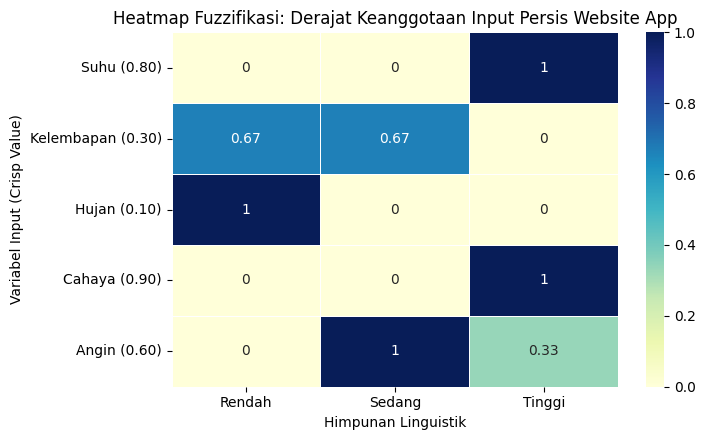

In [2]:
# Simulasi pengujian satu titik crisp input persis seperti pada menu website Streamlit
crisp_values = {
    'Suhu': 0.80,
    'Kelembapan': 0.30,
    'Hujan': 0.10,
    'Cahaya': 0.90,
    'Angin': 0.60
}

fuzzy_sys_heatmap = FuzzyKekeringan()
f_vals_heatmap = fuzzy_sys_heatmap.fuzzify([
    crisp_values['Suhu'], 
    crisp_values['Kelembapan'], 
    crisp_values['Hujan'], 
    crisp_values['Cahaya'], 
    crisp_values['Angin']
])

linguistik = ['Rendah', 'Sedang', 'Tinggi']
variabel = ['Suhu', 'Kelembapan', 'Hujan', 'Cahaya', 'Angin']

heatmap_data = []
for var in variabel:
    row = [f_vals_heatmap[var][ling] for ling in linguistik]
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(
    heatmap_data, 
    index=[f"{var} ({crisp_values[var]:.2f})" for var in variabel], 
    columns=linguistik
)

print("--- SIMULASI OUTPUT INDEKS KEKERINGAN ---")
test_input = [0.80, 0.30, 0.10, 0.90, 0.60]
agg_test = fuzzy_sys_heatmap.evaluate_rules(f_vals_heatmap)
out_mamdani = fuzzy_sys_heatmap.defuzzify_mamdani(agg_test)
out_sugeno = fuzzy_sys_heatmap.defuzzify_sugeno(agg_test)

print(f"Output Indeks Mamdani : {out_mamdani:.2f} / 100")
print(f"Output Indeks Sugeno  : {out_sugeno:.2f} / 100")
print(f"Selisih Deviasi       : {abs(out_mamdani - out_sugeno):.2f}")

plt.figure(figsize=(7.5, 4.5))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", cbar=True, vmin=0, vmax=1, linewidths=0.5)
plt.title("Heatmap Fuzzifikasi: Derajat Keanggotaan Input Persis Website App")
plt.ylabel("Variabel Input (Crisp Value)")
plt.xlabel("Himpunan Linguistik")
plt.tight_layout()
plt.show()